In [4]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [5]:
X, y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=2,
    weights=[0.82, 0.18],  # است ۰ کالس از کمتر (تقلب) ۱ کالس
    flip_y=0.05,  # هابرچسب در گرایانهواقع نویز کمی
    class_sep=0.9,
    random_state=42
)
# بیشتر خوانایی برای هاویژگی گذارینام
feature_names = ['accuracy_pct', 'reaction_time_ms', 'headshot_rate_pct', 'reports_count']

********************************************************************************
SEPTH =  1
              precision    recall  f1-score   support

   Non-fraud       0.77      1.00      0.87        92
       Fraud       0.00      0.00      0.00        28

    accuracy                           0.77       120
   macro avg       0.38      0.50      0.43       120
weighted avg       0.59      0.77      0.67       120


importance features:
  accuracy_pct: 0.0000
  reaction_time_ms: 1.0000
  headshot_rate_pct: 0.0000
  reports_count: 0.0000
********************************************************************************
SEPTH =  4
              precision    recall  f1-score   support

   Non-fraud       0.88      0.99      0.93        92
       Fraud       0.94      0.57      0.71        28

    accuracy                           0.89       120
   macro avg       0.91      0.78      0.82       120
weighted avg       0.90      0.89      0.88       120


importance features:
  accuracy_pct: 

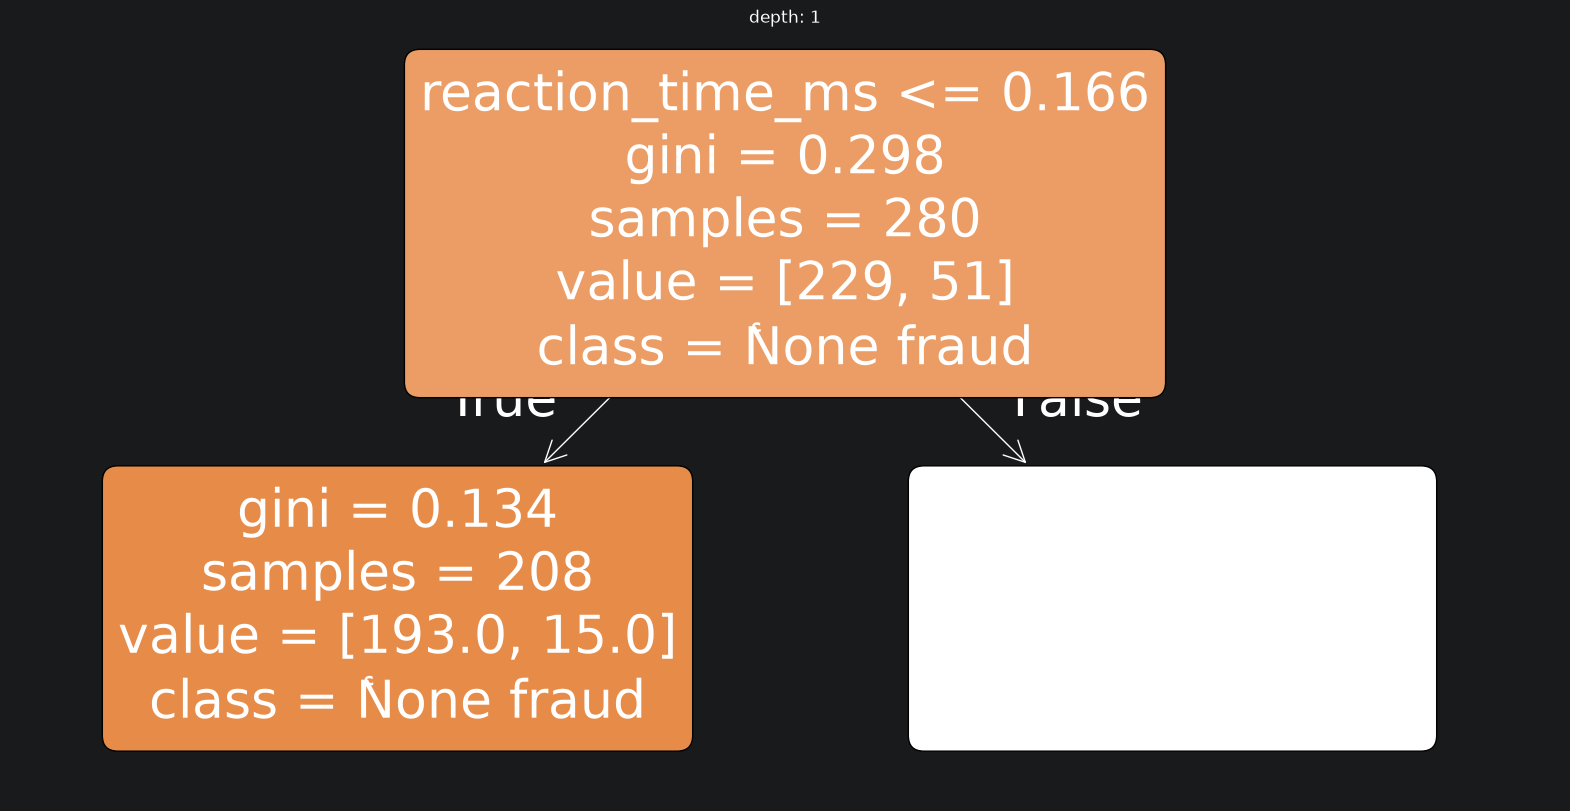

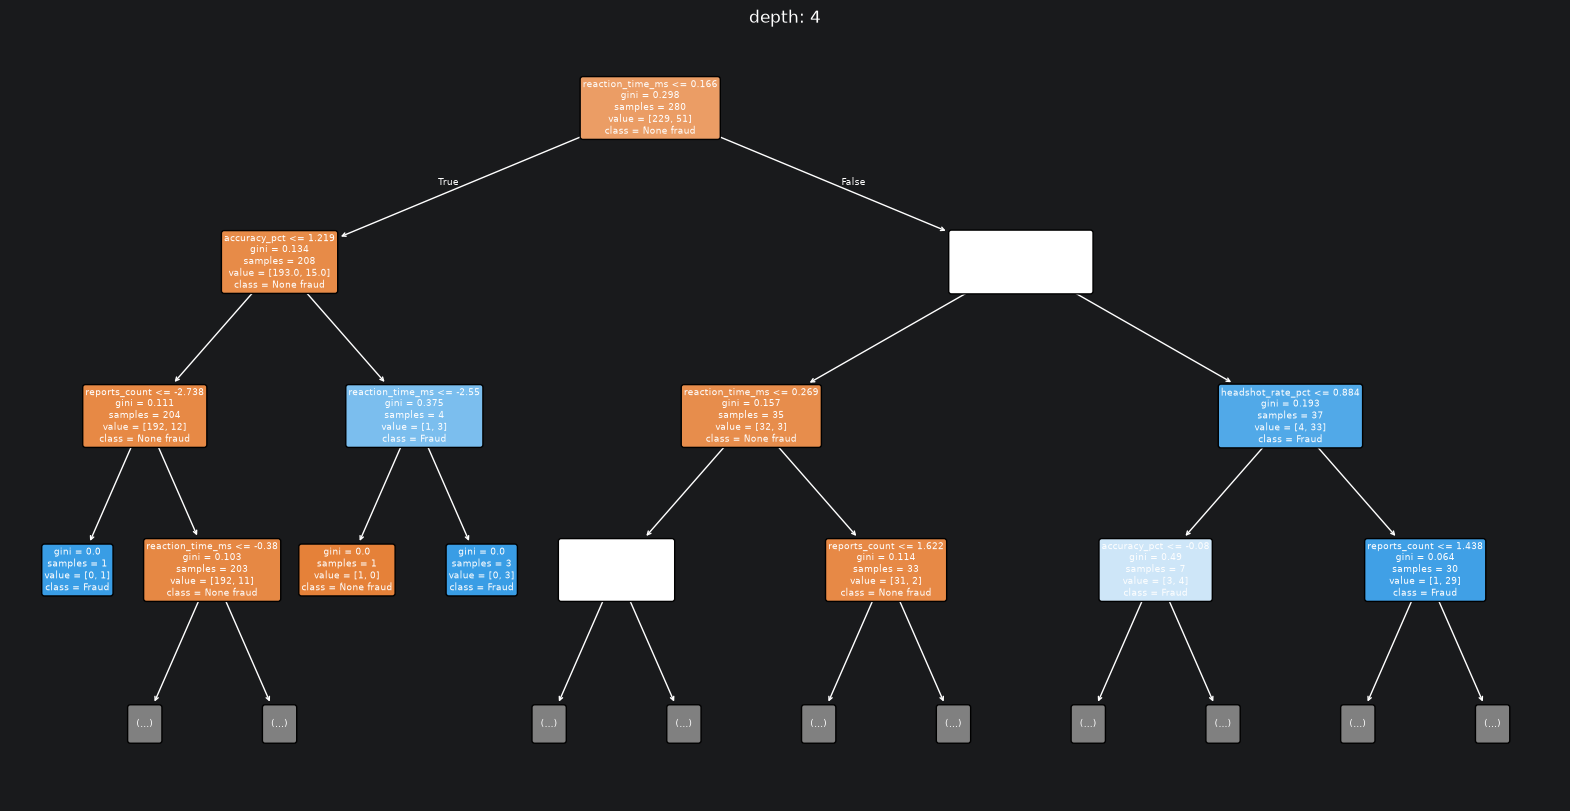

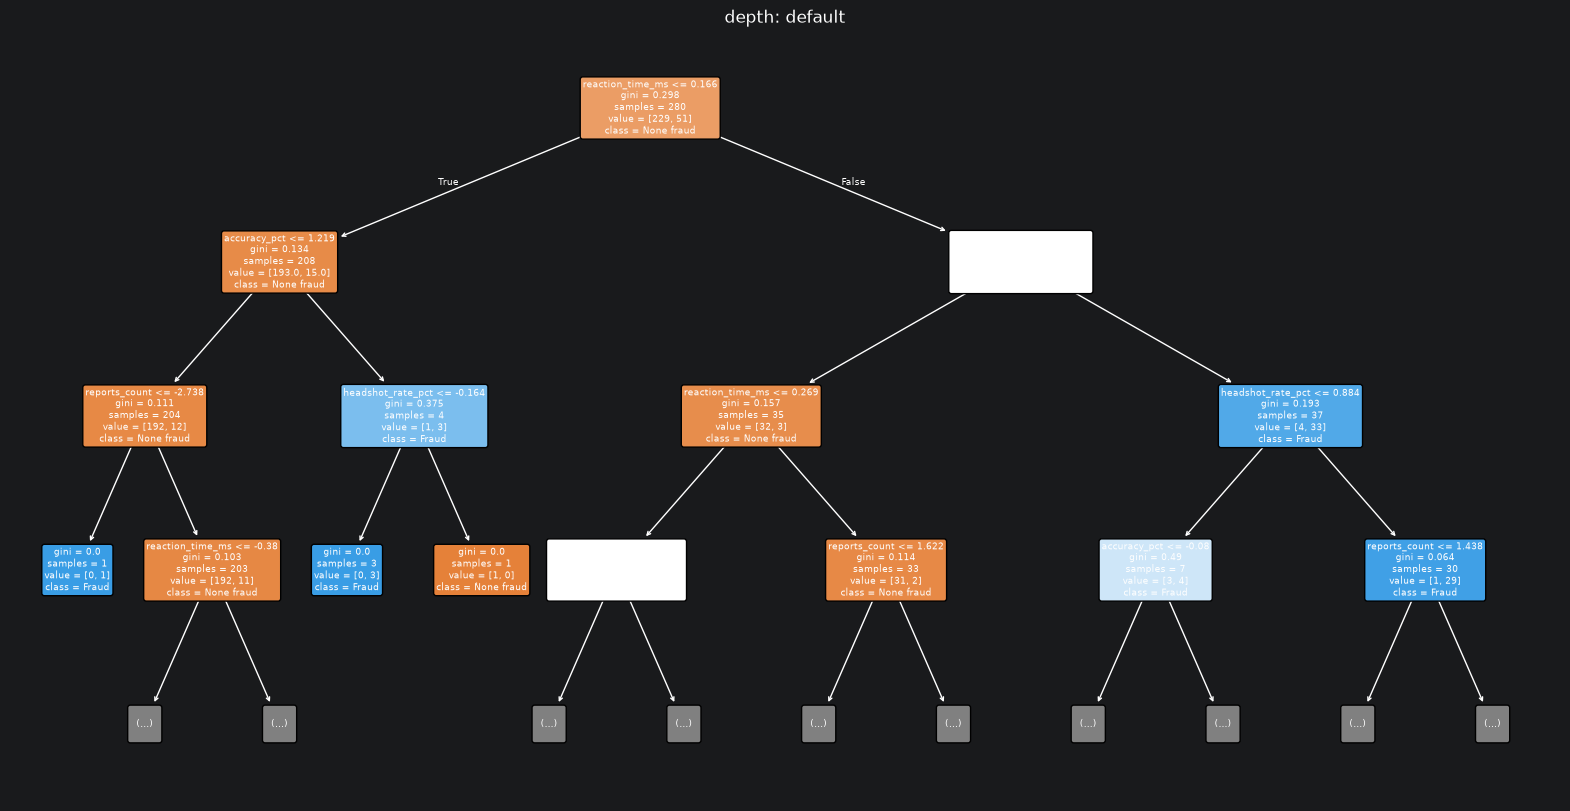

In [6]:


# 1. ایجاد داده‌های شبیه‌سازی شده
X, y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=2,
    weights=[0.82, 0.18],
    flip_y=0.05,
    class_sep=0.9,
    random_state=42
)

feature_names = ['accuracy_pct', 'reaction_time_ms', 'headshot_rate_pct', 'reports_count']

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# print(df.head())

# print(f"fraud count: {sum(df['target'] == 1)}")

X = df.loc[:,feature_names]
y = df.loc[:,'target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for depth in [1, 4, None]:

    if depth is None:
        model = DecisionTreeClassifier(random_state=42)
    else:
        model = DecisionTreeClassifier(random_state=42, max_depth=depth)

    depth_name = "default" if depth is None else depth
    print("*" * 80)
    print("SEPTH = ", depth_name)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(classification_report(y_test, y_pred,
                           target_names=['Non-fraud', 'Fraud'],
                           zero_division=0))
    importance = model.feature_importances_
    print("\nimportance features:")
    for name, imp in zip(feature_names, importance):
        print(f"  {name}: {imp:.4f}")

    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=feature_names, class_names=['ٔNone fraud', 'Fraud'],
              filled=True, rounded=True, max_depth=3)
    plt.title(f"depth: {depth_name}")
    # plt.show()